In [6]:
import numpy as np
import scipy.signal as ssig
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.timeseries import LombScargle
from scipy.signal import lombscargle
from scipy.fft import fft

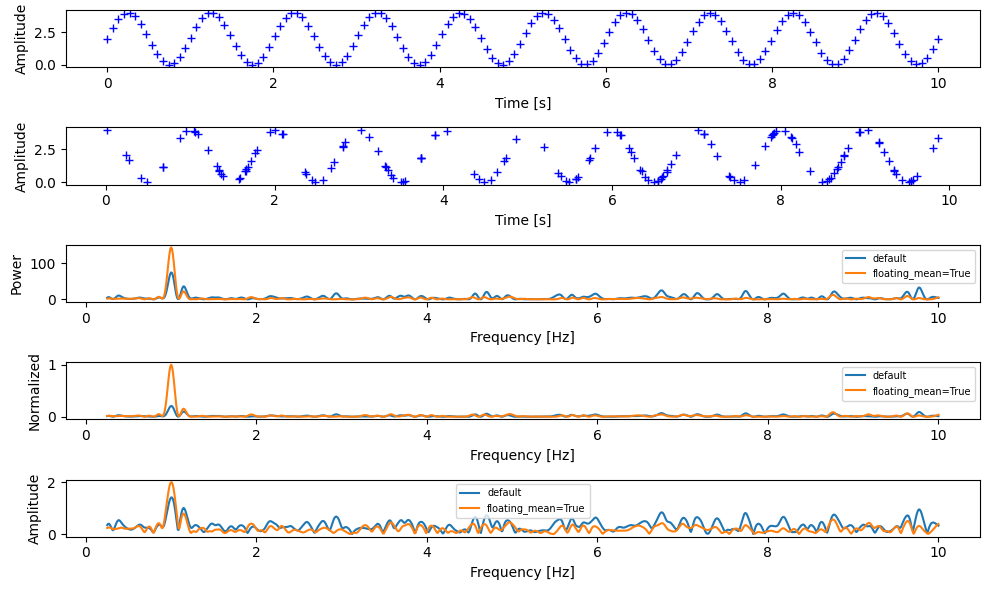

In [ ]:
rng = np.random.default_rng()

A = 2.  # amplitude
c = 2.  # offset
w0 = 2 * np.pi  # 1 Hz in rad/s
nin = 150
nout = 1002

x = np.linspace(0, 10, nin)  # 10 seconds span for time
y = A * np.sin(w0 * x) + c

fig, (ax_t, ax_z, ax_p, ax_n, ax_a) = plt.subplots(5, 1, figsize=(7, 6))

ax_t.plot(x, y, 'b+')
ax_t.set_xlabel('Time [s]')
ax_t.set_ylabel('Amplitude')

x = rng.uniform(0, 10, nin)  # still in seconds
y = A * np.cos(w0 * x) + c
w = np.linspace(0.25, 10, nout) * 2 * np.pi  # convert from Hz to rad/s

from scipy.signal import lombscargle

pgram_power = lombscargle(x, y, w, normalize=False)
pgram_norm = lombscargle(x, y, w, normalize=True)
pgram_amp = lombscargle(x, y, w, normalize='amplitude')
pgram_power_f = lombscargle(x, y, w, normalize=False, floating_mean=True)
pgram_norm_f = lombscargle(x, y, w, normalize=True, floating_mean=True)
pgram_amp_f = lombscargle(x, y, w, normalize='amplitude', floating_mean=True)

ax_z.plot(x, y, 'b+')
ax_z.set_xlabel('Time [s]')
ax_z.set_ylabel('Amplitude')

ax_p.plot(w / (2 * np.pi), pgram_power, label='default')  # convert back to Hz for x-axis
ax_p.plot(w / (2 * np.pi), pgram_power_f, label='floating_mean=True')
ax_p.set_xlabel('Frequency [Hz]')
ax_p.set_ylabel('Power')
ax_p.legend(prop={'size': 7})

ax_n.plot(w / (2 * np.pi), pgram_norm, label='default')
ax_n.plot(w / (2 * np.pi), pgram_norm_f, label='floating_mean=True')
ax_n.set_xlabel('Frequency [Hz]')
ax_n.set_ylabel('Normalized')
ax_n.legend(prop={'size': 7})

ax_a.plot(w / (2 * np.pi), np.abs(pgram_amp), label='default')
ax_a.plot(w / (2 * np.pi), np.abs(pgram_amp_f), label='floating_mean=True')
ax_a.set_xlabel('Frequency [Hz]')
ax_a.set_ylabel('Amplitude')
ax_a.legend(prop={'size': 7})

plt.tight_layout()
plt.show()


In [8]:
## Utility function

def fft_plot(s, fs, name, plottitle, normalized_freq=False):
    """
    Plots the frequency domain representation (magnitude of FFT) of a discrete signal.

    :param s: signal (1D NumPy array)
    :param fs: Sampling frequency in Hz
    :param name: Name of the signal for labeling
    :param plottitle: Title of the plot
    :param normalized_freq: If True, normalize the frequency axis to [0, 1]
    """
    N = len(s)

    # Frequency axis
    f = np.linspace(0, fs, N)

    # Compute FFT
    s_f = fft(s)
    
    N = len(s_f)
    f_final = np.arange(0,N)/N if normalized_freq else f

    # Plot only frequency domain
    plt.figure(figsize=(10, 4))
    plt.plot(f_final, np.abs(s_f))
    plt.title(plottitle)
    plt.xlabel('f [Hz]')
    plt.ylabel('|' + name + '_F(f)|')
    plt.grid(True)
    plt.show()

In [ ]:
## Simulated Data ##
rand = np.random.default_rng(42)

number_samples = 100
variance = 0.1
fs = 100

x = rng.uniform(0, 10*np.pi, nin)
y = A * np.cos(w0*x) + c

t_unevenly = np.array(sorted(100 * rand.random(number_samples)))
t_evenly = np.linspace(0, 1, fs)

# x(t) = sin(2 * pi * t / 100) + noise
# we sample the sinusoid at 100 points but unevenly
y_evenly = np.sin(2 * np.pi * t_evenly)  + variance * rand.standard_normal(number_samples)

# x(t) = sin(2 * pi * t / 100) + noise
# we sample the sinusoid at 100 points but unevenly
y_unevenly = np.sin(2 * np.pi * t_unevenly)  + variance * rand.standard_normal(number_samples)

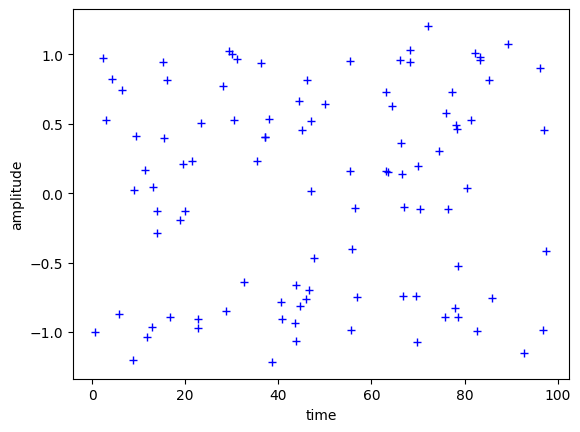

In [16]:
plt.plot(t_unevenly, y_unevenly, 'b+')
plt.xlabel("time")
plt.ylabel("amplitude")
plt.show()

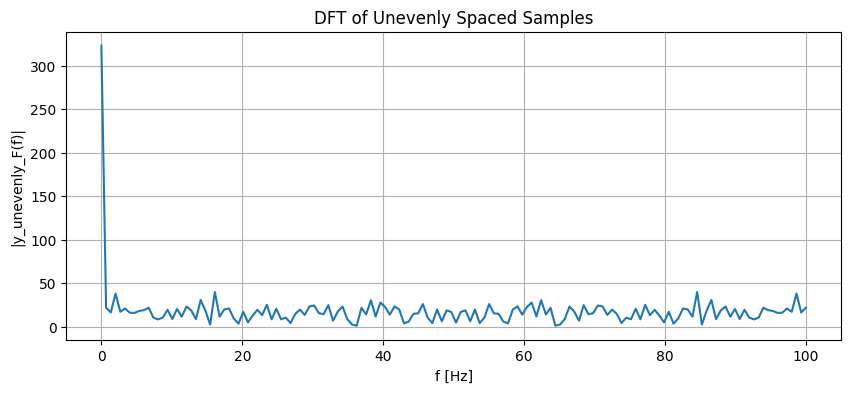

In [11]:
fft_plot(y, 100, 'y_unevenly', 'DFT of Unevenly Spaced Samples', normalized_freq=False)